# 18 &middot; Rotation&ndash;Strain Coordinates: Rescuing a Linear Mode

A **linear mode** is the cheapest way to make a shape move: precompute a
displacement field $\phi$ once, then actuate it as $x(a)=X+a\,\phi$. One scalar
$a$ drives the whole deformation. It is *linear* in $a$ &mdash; and that is
exactly the problem.

Real deformation **rotates**. When a cantilever bends, its tip swings along an
**arc**; each little element *turns*. But a linear mode can only translate every
vertex along a fixed straight line $\phi_i$. For small $a$ a straight line is a
fine approximation to the arc. For large $a$ it is not: the tip shoots off
*tangent* to the arc instead of following it, the beam **stretches**, elements
**shear**, and &mdash; pushed far enough &mdash; **invert** (negative area, turned
inside-out). These are **linearization artifacts**: spurious *strain* that a true
rotation would never produce.

**Rotation&ndash;strain (RS) coordinates** fix this. Given the linearly-actuated
field, look at each element's deformation gradient $F=I+\nabla u$ and split off
its rotation by polar decomposition, $F=R\,S$. The rotation $R$ is the part we
*want*; the symmetric stretch $S$ is the spurious artifact. RS coordinates
**throw $S$ away**: they set the per-element target to $R-I$ and refit a single
displacement field whose Jacobian reproduces *just the rotation*. The linear
mode's "how much each element turned" is **reinterpreted as an actual rotation**,
and the stretch artifact vanishes.

We will (1) pin a beam and pull out its first three linear modes, (2) actuate one
sinusoidally with a swelling-then-shrinking amplitude and watch the shearing /
inflation / inversion artifacts grow, (3) reinterpret that same actuated field
through `rotation_strain_coordinates` and watch the rotation come back while the
spurious strain disappears, and (4) chart the area distortion vs. amplitude to
show RS stays near-rigid where the raw mode blows up.

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.collections import PolyCollection
from matplotlib.colors import TwoSlopeNorm

import simkit
import utils

os.makedirs("media", exist_ok=True)

LIN_C  = "#d62728"   # linear mode (raw) -- has artifacts
RS_C   = "#2ca02c"   # rotation-strain corrected
REST_C = "#bdbdbd"   # ghost of the rest beam
PIN_C  = "#3182bd"   # pinned wall


def signed_areas(V, T):
    '''Per-triangle signed area; negative means the element has flipped.'''
    return 0.5 * ((V[T[:, 1], 0] - V[T[:, 0], 0]) * (V[T[:, 2], 1] - V[T[:, 0], 1])
                - (V[T[:, 1], 1] - V[T[:, 0], 1]) * (V[T[:, 2], 0] - V[T[:, 0], 0]))


class AreaMeshArtist:
    '''A triangle mesh colored per-element by area ratio (deformed / rest).

    Red = inflated, white = volume-preserving (ratio 1, what a rigid rotation
    gives), blue = compressed/inverted. ``update`` moves it to a new state.'''

    def __init__(self, ax, U, T, ratio, vmax=2.0):
        self.T = np.asarray(T)
        self.norm = TwoSlopeNorm(vmin=0.0, vcenter=1.0, vmax=vmax)
        self.coll = PolyCollection([U[f] for f in self.T], array=np.asarray(ratio),
                                   cmap="RdBu_r", norm=self.norm,
                                   edgecolors="0.25", linewidths=0.3, zorder=2)
        ax.add_collection(self.coll)

    def update(self, U, ratio):
        self.coll.set_verts([U[f] for f in self.T])
        self.coll.set_array(np.asarray(ratio))

## A cantilever beam, pinned on the left

A right-triangulated rectangular beam, clamped along its left edge. Pinning is
what makes the modes *interesting*: the free end is what swings through a large
angle, so it is where the linear approximation breaks first.

In [2]:
nx, ny = 48, 7
X, T = utils.triangulated_grid(nx, ny, width=4.0, height=0.6)
n, dim = X.shape
pin = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]   # clamp the whole left edge
print(f"beam: {n} vertices, {T.shape[0]} triangles, {n*dim} DOFs")
print(f"pinned (left wall): {pin.size} vertices")

beam: 336 vertices, 564 triangles, 672 DOFs
pinned (left wall): 7 vertices


## The first three linear modes

`simkit.linear_modal_analysis` solves the generalized eigenproblem
$K\,\phi=\lambda\,M\,\phi$ for the ARAP stiffness $K$ and mass $M$, with the
pinned DOFs eliminated, and returns the lowest modes sorted by eigenvalue
$\lambda$ (squared frequency). The **first** mode is the softest &mdash; the
fundamental bend; the **second** is the next bend (an S-shape with one interior
node); the **third** here is a longitudinal *stretch* mode. None of them carries
any rotation &mdash; they are fixed displacement fields.

Each $\phi$ comes out mass-normalized, so we rescale every mode to unit peak
displacement &mdash; then an actuation amplitude $a$ reads directly as the
distance, in world units, that the most-displaced vertex moves.

eigenvalues (squared frequency): [0.0041 0.132  0.4134]


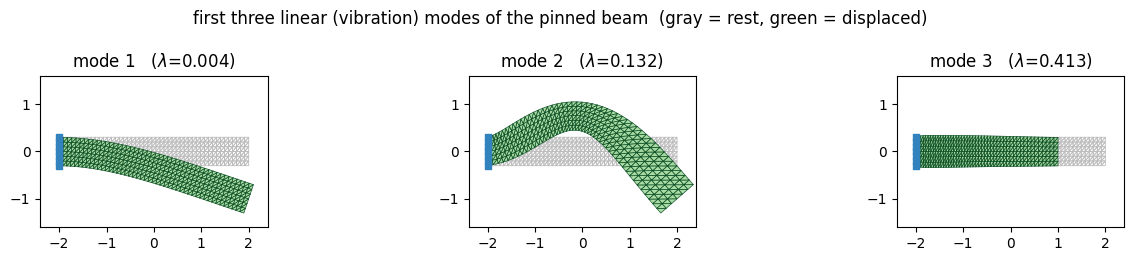

In [8]:
k = 3
E, B = simkit.linear_modal_analysis(X, T, k, bI=pin)
modes = [B[:, i].reshape(n, dim) for i in range(k)]
modes = [m / np.abs(m).max() for m in modes]          # unit peak displacement
print("eigenvalues (squared frequency):", np.round(E[:k], 4))

fig, axes = plt.subplots(1, k, figsize=(13, 2.6))
amp_show = 1.0
for i, (ax, m) in enumerate(zip(axes, modes)):
    utils.setup_axes(ax, (-2.4, 2.4), (-1.6, 1.6),
                     title=f"mode {i+1}   ($\\lambda$={E[i]:.3f})", grid=False)
    ax.add_collection(PolyCollection([X[f] for f in T], facecolors="none",
                                     edgecolors=REST_C, linewidths=0.6, zorder=1))
    Um = X + amp_show * m
    ax.add_collection(PolyCollection([Um[f] for f in T], facecolors="#a1d99b",
                                     edgecolors="#00441b", linewidths=0.5,
                                     alpha=0.9, zorder=2))
    ax.scatter(X[pin, 0], X[pin, 1], s=22, color=PIN_C, marker="s", zorder=4)
fig.suptitle("first three linear (vibration) modes of the pinned beam  "
             "(gray = rest, green = displaced)")
fig.tight_layout(); fig.savefig("media/18_modes.png", dpi=130, bbox_inches="tight")
plt.show()

## Actuate the first mode &mdash; sinusoidally, swelling then fading

We drive the fundamental bending mode with

$$ a(t) \;=\; A_{\max}\,\sin\!\big(2\pi t\big),\qquad t\in[0,1], $$

one full sine period: the tip swings **up** to $+A_{\max}$, back through rest,
**down** to $-A_{\max}$, and home again &mdash; the actuation magnitude rising,
then falling, then rising, then falling. We push $A_{\max}$ deliberately large so
the artifact is unmistakable.

Each frame is colored by **area ratio** (deformed element area / rest area). A
*rigid rotation preserves area*, so a faithful bend should stay **white**
(ratio&nbsp;1) everywhere. Watch instead: as the tip swings out, the elements near
it flush **red** &mdash; the straight-line mode *stretches* the beam because the
tip leaves along the tangent instead of riding the arc. The trace on the right
tracks the worst element; it spikes at every swing and only returns to 1 as the
beam passes back through rest.

raw linear mode at A_max=3.0:  peak area ratio 2.03x   min element area ratio +0.82  (negative => inverted elements)
saved media/18_linear_artifacts.mp4



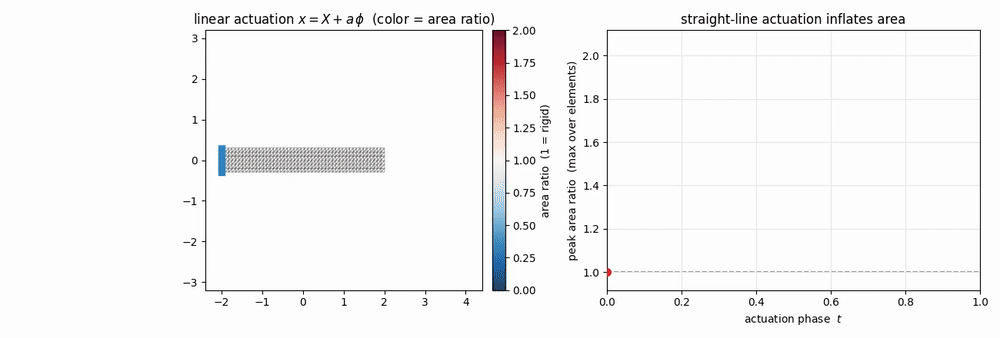

In [9]:
A_max =3.0
mode = modes[0]
n_frames = 61
tt = np.linspace(0.0, 1.0, n_frames)
a_t = A_max * np.sin(2.0 * np.pi * tt)               # one full sine period
A0 = signed_areas(X, T)

states_lin, ratio_lin, peak_lin = [], [], []
for a in a_t:
    U = X + a * mode
    r = signed_areas(U, T) / A0
    states_lin.append(U); ratio_lin.append(r); peak_lin.append(r.max())
peak_lin = np.array(peak_lin)
print(f"raw linear mode at A_max={A_max}:  peak area ratio {peak_lin.max():.2f}x"
      f"   min element area ratio {min(r.min() for r in ratio_lin):+.2f}"
      f"  (negative => inverted elements)")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.4),
                               gridspec_kw={"width_ratios": [1.35, 1]})
utils.setup_axes(axL, (-2.4, 4.4), (-3.2, 3.2),
                 title="linear actuation $x=X+a\\,\\phi$  (color = area ratio)", grid=False)
art = AreaMeshArtist(axL, states_lin[0], T, ratio_lin[0], vmax=2.0)
axL.scatter(X[pin, 0], X[pin, 1], s=26, color=PIN_C, marker="s", zorder=4)
fig.colorbar(art.coll, ax=axL, fraction=0.046, pad=0.02,
             label="area ratio  (1 = rigid)")
trace = utils.TracePlot(axR, tt, {"raw linear mode": peak_lin},
                        colors={"raw linear mode": LIN_C},
                        xlabel="actuation phase  $t$", ylabel="peak area ratio  (max over elements)",
                        title="straight-line actuation inflates area")
axR.axhline(1.0, color="0.5", ls="--", lw=1.2, zorder=1)

def update(i):
    art.update(states_lin[i], ratio_lin[i]); trace.update(i)
    return ()

anim = FuncAnimation(fig, update, frames=n_frames, interval=1000/20, blit=False)
fig.tight_layout()
out = utils.save_anim(anim, "media/18_linear_artifacts.mp4", fps=20)
print("saved", out)
update(int(np.argmax(peak_lin)))   # freeze on a peak-swing frame for the saved still
fig.savefig("media/18_linear_artifacts.png", dpi=130, bbox_inches="tight")
html = utils.show_anim(anim, fps=18, width=1000)
plt.close(fig)
html

## Reinterpret the actuation in rotation&ndash;strain coordinates

The red flush is **spurious strain**. Here is how RS coordinates remove it,
element by element:

1. From the linear field $u=a\,\phi$ form the deformation gradient
   $F=I+\nabla u$ on every element (`deformation_jacobian` supplies $\nabla u$).
2. Extract the **rotation** by polar decomposition $F=R\,S$ (in 2D this is just
   the angle of $F$'s antisymmetric part). $R$ is the orientation the linear
   field gave that element; $S$ is the leftover stretch/shear &mdash; the
   artifact.
3. Set the per-element target $Y=R-I$ &mdash; *rotation only, no stretch* &mdash;
   and solve one small least-squares fit for the displacement $u_{\text{rs}}$
   whose Jacobian best matches $Y$ everywhere (a pinned Poisson-type solve,
   prefactored once in `RSPrecompute`).

The result reads the linear mode's *rotation content* and rebuilds a globally
consistent displacement from it alone. `simkit.rotation_strain_coordinates`
returns that $u_{\text{rs}}$ (and a reusable precompute). We run it on **every
frame of the same actuation** and compare side by side.

raw linear : peak area ratio 2.03x
RS-corrected: peak area ratio 1.19x   (rotation preserved, ~rigid)
saved media/18_rs_vs_linear.mp4



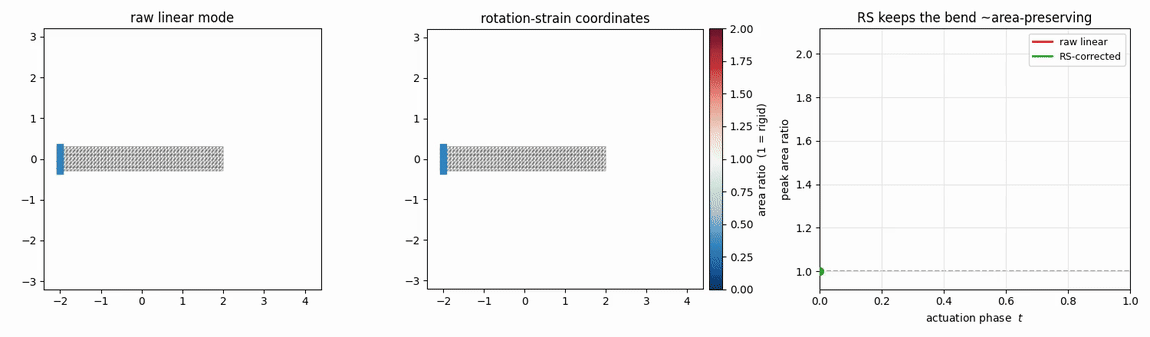

In [10]:
states_rs, ratio_rs, peak_rs = [], [], []
pre = None                                            # RSPrecompute: build once, reuse
for a in a_t:
    u = (a * mode).reshape(-1)
    u_rs, pre = simkit.rotation_strain_coordinates(X, T, u, pinned=pin, pre=pre)
    U = X + u_rs
    r = signed_areas(U, T) / A0
    states_rs.append(U); ratio_rs.append(r); peak_rs.append(r.max())
peak_rs = np.array(peak_rs)
print(f"raw linear : peak area ratio {peak_lin.max():.2f}x")
print(f"RS-corrected: peak area ratio {peak_rs.max():.2f}x   (rotation preserved, ~rigid)")

fig, (axA, axB, axR) = plt.subplots(1, 3, figsize=(15, 4.4),
                                    gridspec_kw={"width_ratios": [1, 1, 1.05]})
utils.setup_axes(axA, (-2.4, 4.4), (-3.2, 3.2), title="raw linear mode", grid=False)
utils.setup_axes(axB, (-2.4, 4.4), (-3.2, 3.2), title="rotation-strain coordinates", grid=False)
aA = AreaMeshArtist(axA, states_lin[0], T, ratio_lin[0], vmax=2.0)
aB = AreaMeshArtist(axB, states_rs[0],  T, ratio_rs[0],  vmax=2.0)
for ax in (axA, axB):
    ax.scatter(X[pin, 0], X[pin, 1], s=26, color=PIN_C, marker="s", zorder=4)
fig.colorbar(aB.coll, ax=axB, fraction=0.046, pad=0.02, label="area ratio  (1 = rigid)")
trace = utils.TracePlot(axR, tt, {"raw linear": peak_lin, "RS-corrected": peak_rs},
                        colors={"raw linear": LIN_C, "RS-corrected": RS_C},
                        xlabel="actuation phase  $t$", ylabel="peak area ratio",
                        title="RS keeps the bend ~area-preserving")
axR.axhline(1.0, color="0.5", ls="--", lw=1.2, zorder=1)

def update(i):
    aA.update(states_lin[i], ratio_lin[i])
    aB.update(states_rs[i],  ratio_rs[i])
    trace.update(i)
    return ()

anim = FuncAnimation(fig, update, frames=n_frames, interval=1000/20, blit=False)
fig.tight_layout()
out = utils.save_anim(anim, "media/18_rs_vs_linear.mp4", fps=20)
print("saved", out)
update(int(np.argmax(peak_lin)))   # freeze on a peak-swing frame for the saved still
fig.savefig("media/18_rs_vs_linear.png", dpi=130, bbox_inches="tight")
html = utils.show_anim(anim, fps=18, width=1150)
plt.close(fig)
html

## How bad does it get? Distortion vs. amplitude

The animation is one amplitude sweep; this is the whole story in one chart. For a
range of actuation amplitudes $a$ we measure the **worst element area distortion**
$\max_e |r_e - 1|$ for each of the three modes, raw vs. RS-corrected.

The raw linear curves climb without bound &mdash; distortion grows roughly
*linearly* with $a$, and higher modes (more curvature packed into the same beam)
diverge fastest, even flipping elements. The RS curves stay low and flat: the fit
targets a pure rotation at every amplitude, so the reconstructed bend is
near-area-preserving no matter how hard we drive it.

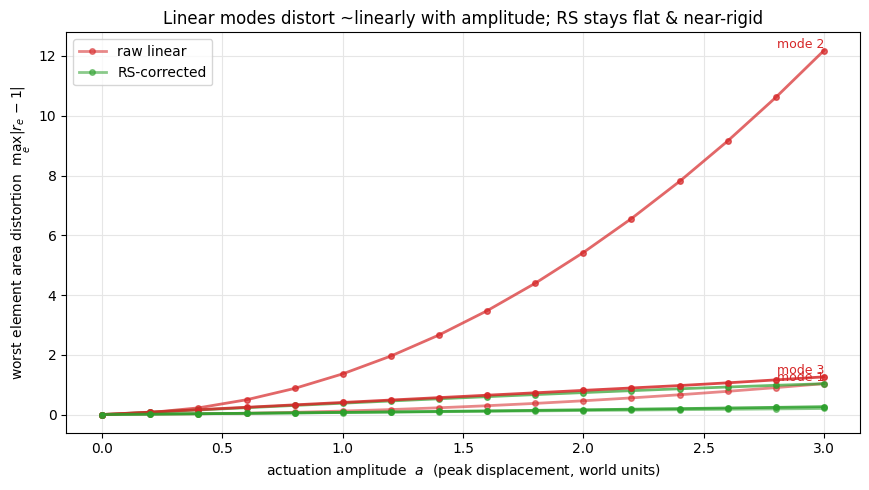

In [6]:
amps = np.linspace(0.0, 3.0, 16)
fig, ax = plt.subplots(figsize=(8.8, 5.0))
pres = [None, None, None]
for i, m in enumerate(modes):
    d_lin, d_rs = [], []
    for a in amps:
        U = X + a * m
        d_lin.append(np.abs(signed_areas(U, T) / A0 - 1.0).max())
        u_rs, pres[i] = simkit.rotation_strain_coordinates(
            X, T, (a * m).reshape(-1), pinned=pin, pre=pres[i])
        d_rs.append(np.abs(signed_areas(X + u_rs, T) / A0 - 1.0).max())
    ax.plot(amps, d_lin, "-o", color=LIN_C, lw=2, ms=4, alpha=0.55 + 0.15*i,
            label="raw linear" if i == 0 else None)
    ax.plot(amps, d_rs, "-o", color=RS_C, lw=2, ms=4, alpha=0.55 + 0.15*i,
            label="RS-corrected" if i == 0 else None)
    ax.annotate(f"mode {i+1}", (amps[-1], d_lin[-1]), color=LIN_C,
                fontsize=9, ha="right", va="bottom")
ax.set_xlabel("actuation amplitude  $a$  (peak displacement, world units)")
ax.set_ylabel("worst element area distortion  $\\max_e |r_e-1|$")
ax.set_title("Linear modes distort ~linearly with amplitude; RS stays flat & near-rigid")
ax.grid(True, color="0.9"); ax.legend(loc="upper left")
fig.tight_layout(); fig.savefig("media/18_distortion_vs_amp.png", dpi=130, bbox_inches="tight")
plt.show()

### Takeaways

* A **linear mode** $x=X+a\,\phi$ moves every vertex along a fixed straight line.
  Cheap and great for small $a$, but rotation is **nonlinear** in position, so at
  large $a$ the straight line departs the true arc: the shape **stretches,
  shears, and inverts**. These linearization artifacts show up directly as area
  ratios far from 1.
* **Rotation&ndash;strain coordinates** read the *rotation* $R$ out of the linear
  field's deformation gradient $F=R\,S$, discard the spurious stretch $S$, and
  refit a displacement whose Jacobian is $R-I$. The actuation's "how much each
  element turned" is reinterpreted as an **actual rotation**.
* The payoff: the same one-scalar actuation now bends the beam along an arc and
  stays near area-preserving at *every* amplitude, where the raw mode's
  distortion grows without bound (worst for the high-curvature modes).
* Use it whenever a cheap linear subspace has to undergo **large rotation**
  &mdash; actuated characters, cables, tentacles, modal animation &mdash; to get
  rotation-aware motion at linear-mode cost. It is the same lesson as the
  skinning-eigenmodes tutorial (17), reached from the other direction: there we
  *built* a rotation-capable basis; here we *repair* a rotation-blind one after
  the fact.

---
RS coordinates turn a rotation-blind linear mode into a rotation-aware one by
polar-decomposing its Jacobian and keeping only the turn &mdash; the same
neo-Hookean-era kinematics (tutorials 1&ndash;3), now in service of cheap
actuation.